[CpuDevice(id=0)]


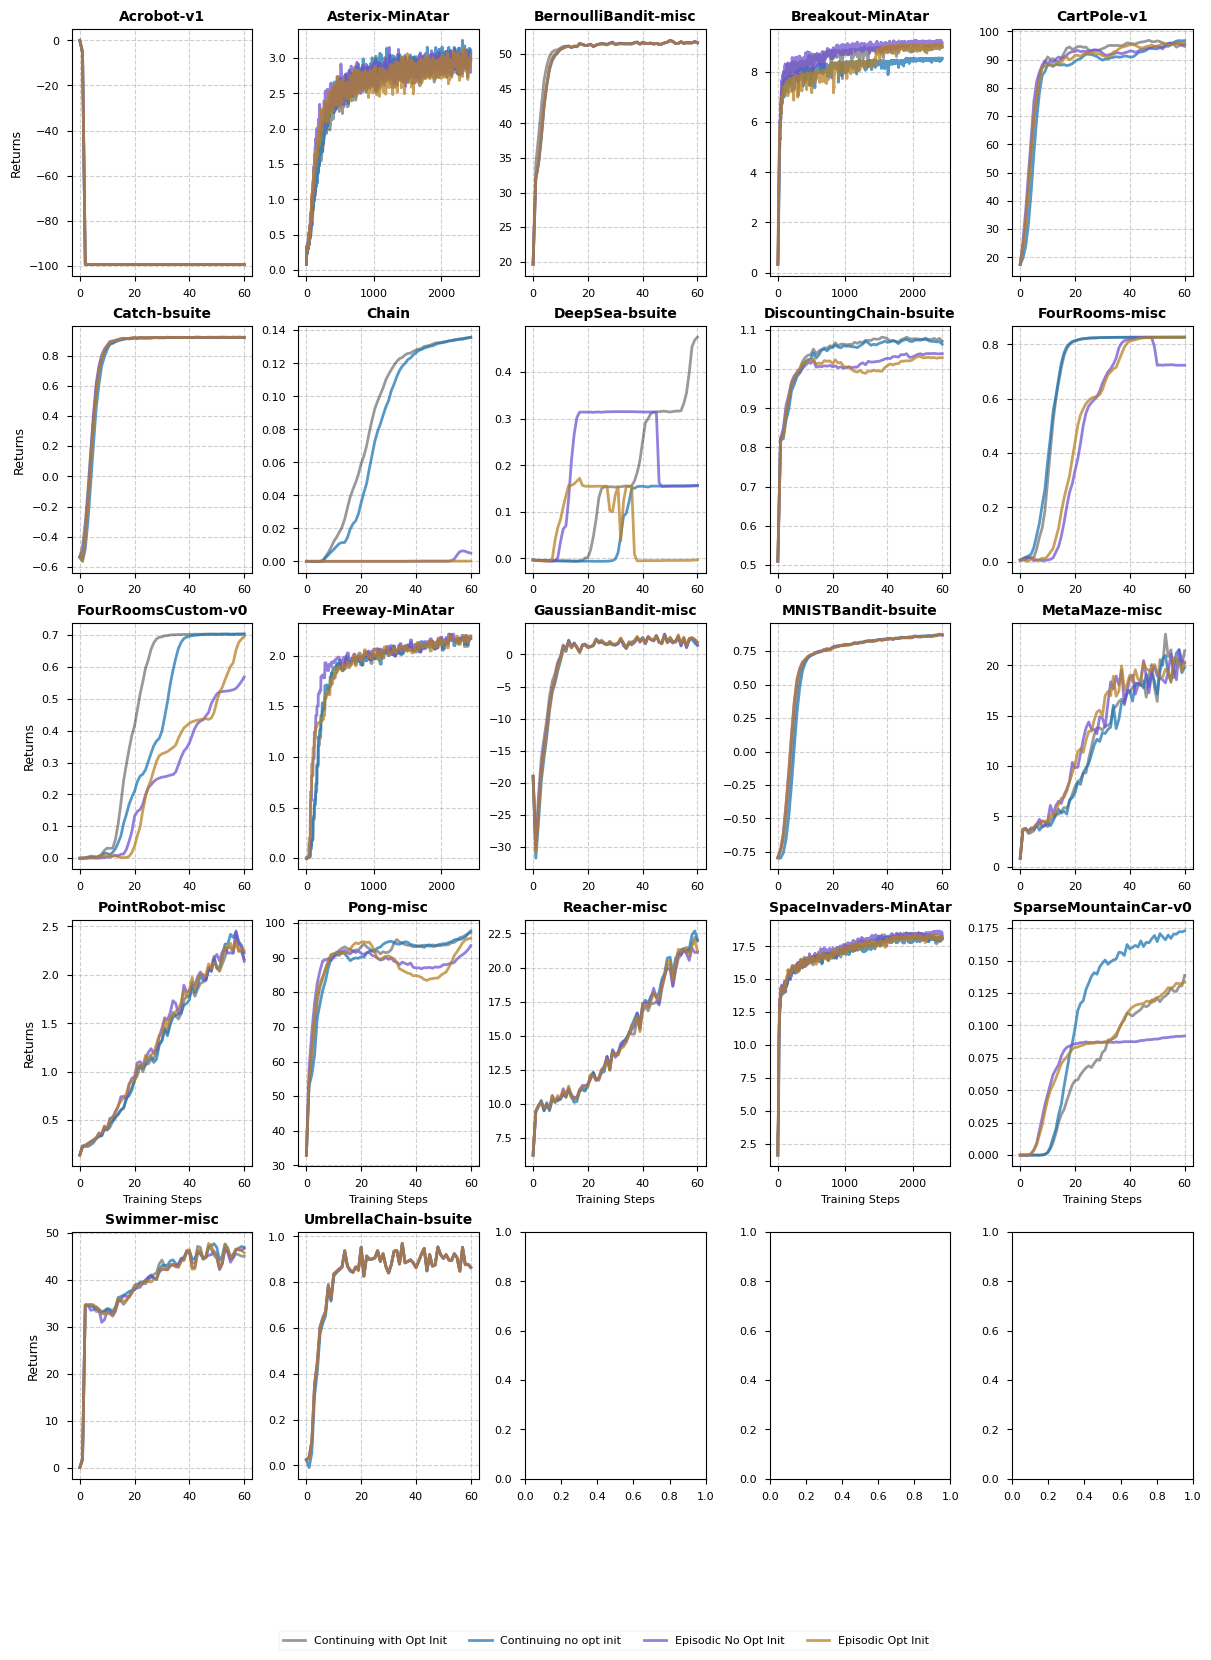

In [25]:
import matplotlib.pyplot as plt
import numpy as np
import jax
import os
import json
import cloudpickle
import sys
sys.path.append(os.path.abspath(".."))
import os
os.environ["JAX_PLATFORMS"] = "cpu"
from IPython.display import FileLink, display, HTML
from mail import *
import jax
import jax.numpy as jnp
print(jax.devices())  # Should list CPU devices only
from plot_utils import plot_experiments, load_run_data, make_table
import matplotlib.pyplot as plt
import numpy as np
from core.configs import CONFIG_REGISTRY



# --- Define runs once ---
RUNS = [
    {"run_dir": "3_13_cov_lstd/cont_opt_init", "name": "Continuing with Opt Init", "color": "black", "alpha": 0.4},
    {"run_dir": "3_13_cov_lstd/cont_no_opt_init", "name": "Continuing no opt init", "color": "#1f77b4", "alpha": 0.75},
    {"run_dir": "3_13_cov_lstd/ep_no_opt_init", "name": "Episodic No Opt Init", "color": "#7154d1", "alpha": 0.75},
    {"run_dir": "3_13_cov_lstd/ep_opt_init", "name": "Episodic Opt Init", "color": "#b88027", "alpha": 0.75},
]

envs = set()
for k in CONFIG_REGISTRY:
    envs = envs.union(set(CONFIG_REGISTRY[k]['envs']))
envs = sorted(envs)


plt.style.use('seaborn-v0_8-paper')
n_rows = 5
n_cols = 5
fig, axes = plt.subplots(n_rows, n_cols, figsize=(4*3, 5*3), constrained_layout=True)
axes = axes.flatten()

handles, labels = [], []

for i, ENV in enumerate(envs):
    ax = axes[i]

    try:
        for run in RUNS:
            config, metrics = load_run_data(run["run_dir"], ENV)

            # Average across seeds if needed
            if run["name"] == "PPO":
                metrics_avg = jax.tree.map(lambda x: x.mean(0), metrics)
                rets = metrics_avg['returned_discounted_episode_returns']
            else:
                rets = metrics['returned_discounted_episode_returns'].mean(0)

            line, = ax.plot(
                rets,
                label=run["name"],
                color=run.get("color", None),
                alpha=run.get("alpha", 1.0),
                linewidth=2,
            )

            # Save legend handles once
            if i == 0:
                handles.append(line)
                labels.append(run["name"])

        # --- Formatting ---
        ax.set_title(ENV, fontweight='bold', fontsize=10)

        row = i // n_cols
        col = i % n_rows

        # X labels only on bottom row
        if row == 3:
            ax.set_xlabel('Training Steps', fontsize=8)
        else:
            ax.set_xlabel('')

        # Y labels only on left column
        if col == 0:
            ax.set_ylabel('Returns', fontsize=9)
        else:
            ax.set_ylabel('')

        ax.grid(True, linestyle='--', alpha=0.6)

    except Exception as e:
        ax.text(0.5, 0.5, f"Missing\n{ENV}", ha='center')
        print(f"Error loading {ENV}: {e}")

# --- Shared legend ---
fig.legend(
    handles, labels,
    loc='lower center',
    ncol=len(RUNS),
    bbox_to_anchor=(0.5, -0.1),
    frameon=True,
    fontsize=8
)

plt.show()

# fig.savefig('../figures/debug_results_with_cont.pdf', bbox_inches='tight', dpi=300)
# email_pdf('../figures/debug_results_with_cont.pdf')

In [26]:
envs.remove('DeepSea-bsuite')
envs

['Acrobot-v1',
 'Asterix-MinAtar',
 'BernoulliBandit-misc',
 'Breakout-MinAtar',
 'CartPole-v1',
 'Catch-bsuite',
 'Chain',
 'DiscountingChain-bsuite',
 'FourRooms-misc',
 'FourRoomsCustom-v0',
 'Freeway-MinAtar',
 'GaussianBandit-misc',
 'MNISTBandit-bsuite',
 'MetaMaze-misc',
 'PointRobot-misc',
 'Pong-misc',
 'Reacher-misc',
 'SpaceInvaders-MinAtar',
 'SparseMountainCar-v0',
 'Swimmer-misc',
 'UmbrellaChain-bsuite']

Error loading Breakout-MinAtar: [Errno 2] No such file or directory: '../results/3_18_cov_lstd/ep/Breakout-MinAtar/config.json'
Error loading Freeway-MinAtar: [Errno 2] No such file or directory: '../results/3_18_cov_lstd/ep/Freeway-MinAtar/config.json'
Error loading Chain: [Errno 2] No such file or directory: '../results/3_18_cov_lstd/ep/Chain/config.json'
Error loading SpaceInvaders-MinAtar: [Errno 2] No such file or directory: '../results/3_18_cov_lstd/ep/SpaceInvaders-MinAtar/config.json'
Error loading Asterix-MinAtar: [Errno 2] No such file or directory: '../results/3_18_cov_lstd/ep/Asterix-MinAtar/config.json'


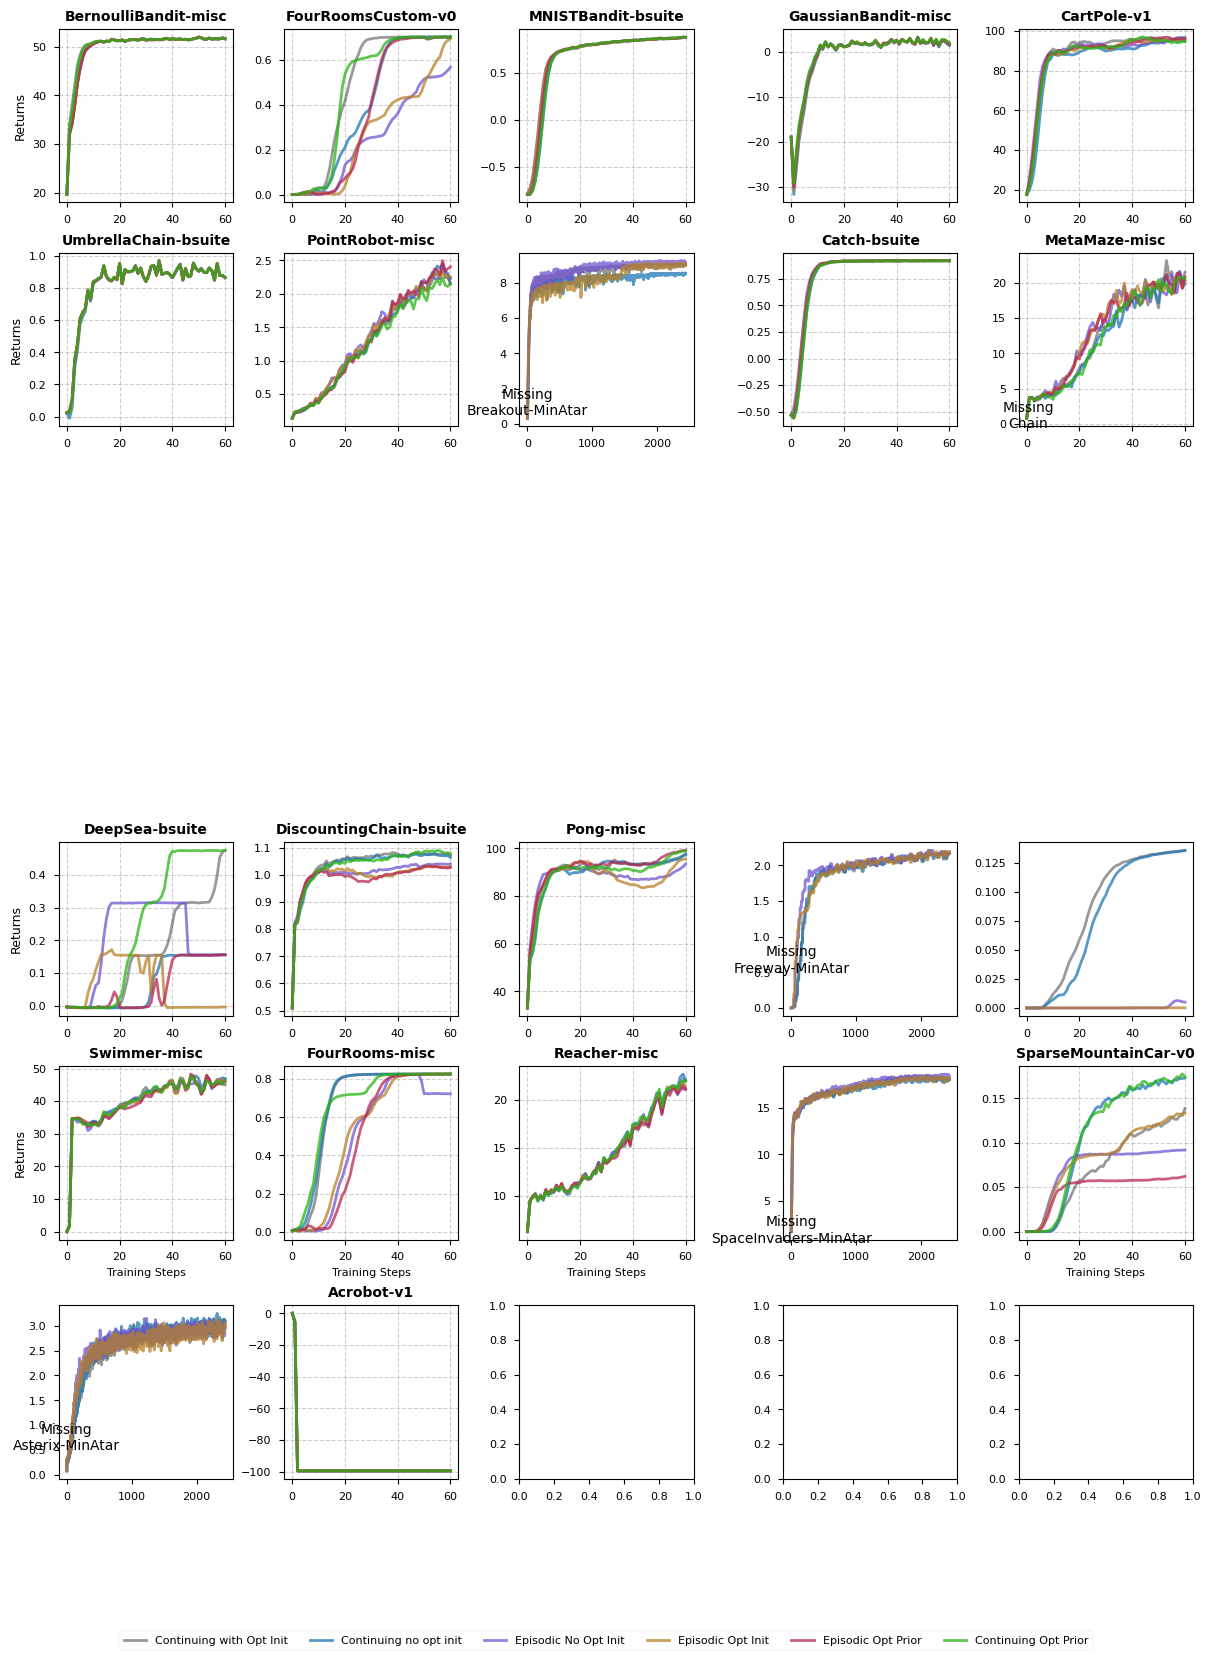

In [27]:


# --- Define runs once ---
RUNS = [
    {"run_dir": "3_13_cov_lstd/cont_opt_init", "name": "Continuing with Opt Init", "color": "black", "alpha": 0.4},
    {"run_dir": "3_13_cov_lstd/cont_no_opt_init", "name": "Continuing no opt init", "color": "#1f77b4", "alpha": 0.75},
    {"run_dir": "3_13_cov_lstd/ep_no_opt_init", "name": "Episodic No Opt Init", "color": "#7154d1", "alpha": 0.75},
    {"run_dir": "3_13_cov_lstd/ep_opt_init", "name": "Episodic Opt Init", "color": "#b88027", "alpha": 0.75},
    {"run_dir": "3_18_cov_lstd/ep", "name": "Episodic Opt Prior", "color": "#b82750", "alpha": 0.75},
    {"run_dir": "3_18_cov_lstd/cont", "name": "Continuing Opt Prior", "color": "#28b612", "alpha": 0.75},
]

envs = set()
for k in CONFIG_REGISTRY:
    envs = envs.union(set(CONFIG_REGISTRY[k]['envs']))


plt.style.use('seaborn-v0_8-paper')
n_rows = 5
n_cols = 5
fig, axes = plt.subplots(n_rows, n_cols, figsize=(4*3, 5*3), constrained_layout=True)
axes = axes.flatten()

handles, labels = [], []

for i, ENV in enumerate(envs):
    ax = axes[i]

    try:
        for run in RUNS:
            config, metrics = load_run_data(run["run_dir"], ENV)

            # Average across seeds if needed
            if run["name"] == "PPO":
                metrics_avg = jax.tree.map(lambda x: x.mean(0), metrics)
                rets = metrics_avg['returned_discounted_episode_returns']
            else:
                rets = metrics['returned_discounted_episode_returns'].mean(0)

            line, = ax.plot(
                rets,
                label=run["name"],
                color=run.get("color", None),
                alpha=run.get("alpha", 1.0),
                linewidth=2,
            )

            # Save legend handles once
            if i == 0:
                handles.append(line)
                labels.append(run["name"])

        # --- Formatting ---
        ax.set_title(ENV, fontweight='bold', fontsize=10)

        row = i // n_cols
        col = i % n_rows

        # X labels only on bottom row
        if row == 3:
            ax.set_xlabel('Training Steps', fontsize=8)
        else:
            ax.set_xlabel('')

        # Y labels only on left column
        if col == 0:
            ax.set_ylabel('Returns', fontsize=9)
        else:
            ax.set_ylabel('')

        ax.grid(True, linestyle='--', alpha=0.6)

    except Exception as e:
        ax.text(0.5, 0.5, f"Missing\n{ENV}", ha='center')
        print(f"Error loading {ENV}: {e}")

# --- Shared legend ---
fig.legend(
    handles, labels,
    loc='lower center',
    ncol=len(RUNS),
    bbox_to_anchor=(0.5, -0.1),
    frameon=True,
    fontsize=8
)

plt.show()
